In [1]:
import os
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

def make_combination(config_dict):
    keys, values = zip(*config_dict.items())
    return [dict(zip(keys, v)) for v in itertools.product(*values)]

In [2]:
UEA_MTSC30 = ['EthanolConcentration',
              'FaceDetection',
              'Handwriting',
              'Heartbeat',
              'JapaneseVowels',
              'PEMS-SF',
              'SelfRegulationSCP1',
              'SelfRegulationSCP2',
              'SpokenArabicDigits',
              'UWaveGestureLibrary',
              'ArticularyWordRecognition',
              'AtrialFibrillation',
              'BasicMotions',
              'CharacterTrajectories',
              'Cricket',
              'DuckDuckGeese',
              'EigenWorms',
              'Epilepsy',
              'ERing',
              'FingerMovements',
              'HandMovementDirection',
              'InsectWingbeat',
              'Libras',
              'LSST',
              'MotorImagery',
              'NATOPS',
              'PenDigits',
              'PhonemeSpectra',
              'RacketSports',
              'StandWalkJump']

In [3]:
from omegaconf import OmegaConf
data_info = OmegaConf.load(f"../data_classification.yaml")

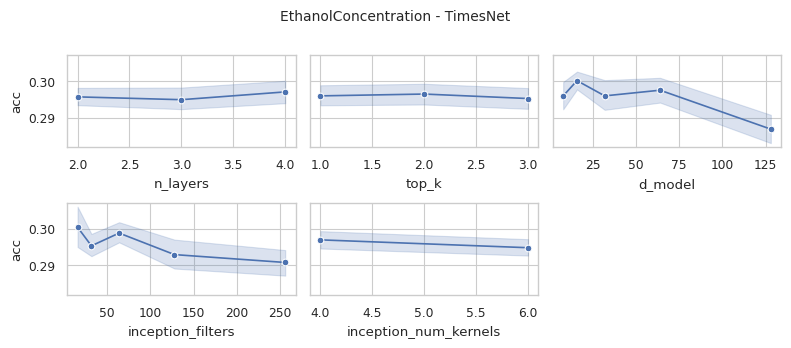

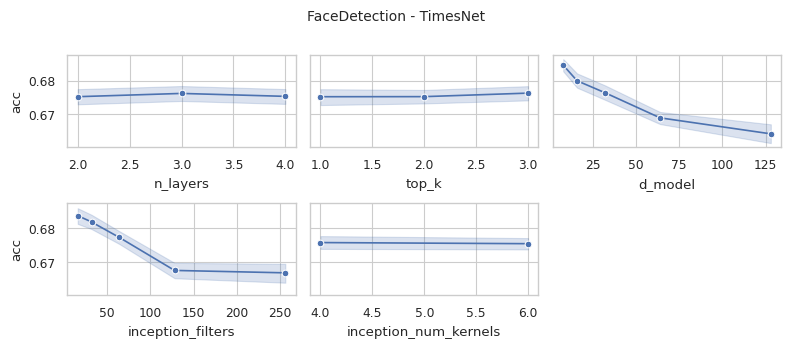

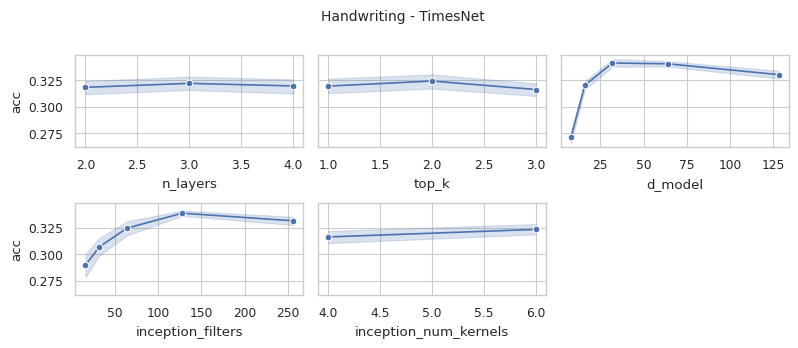

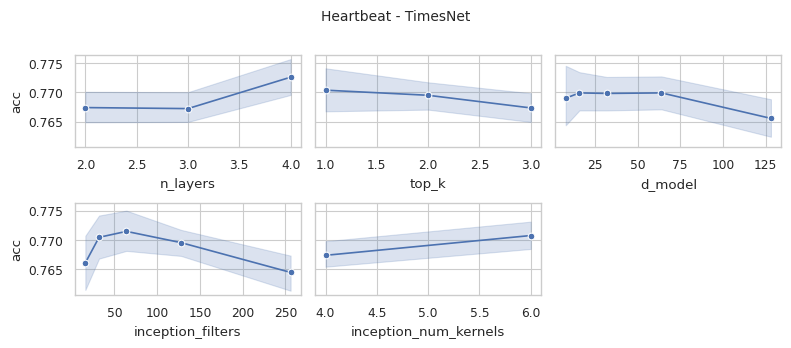

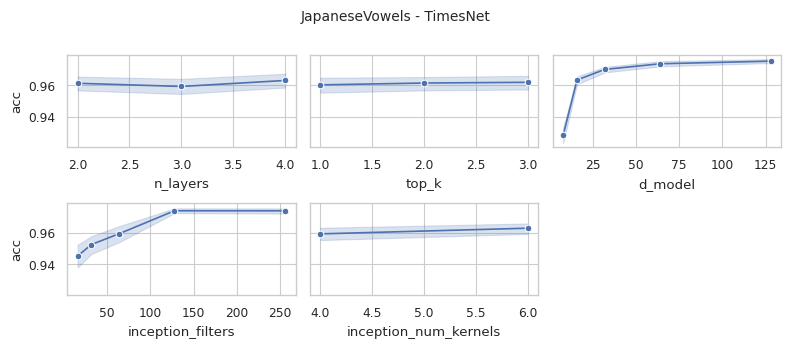

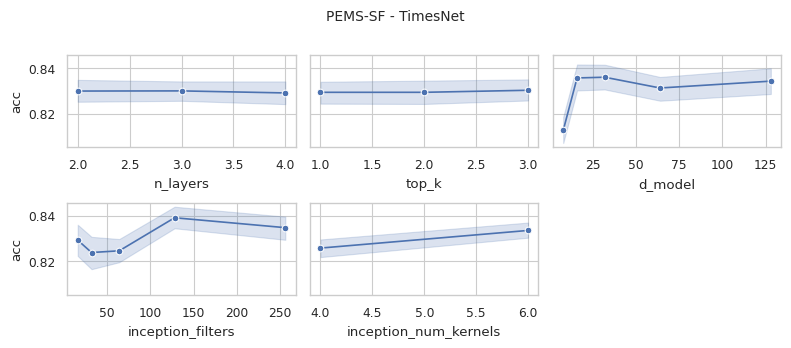

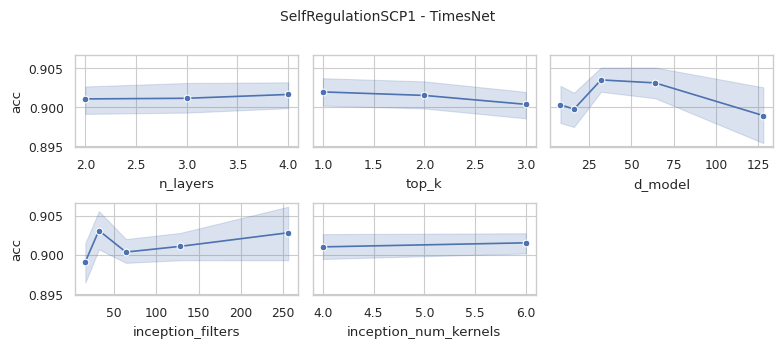

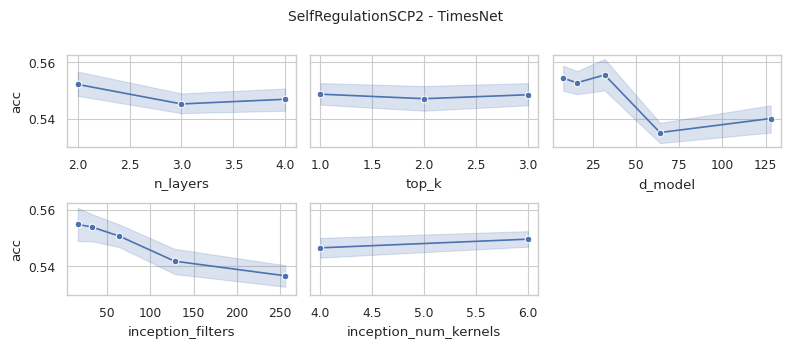

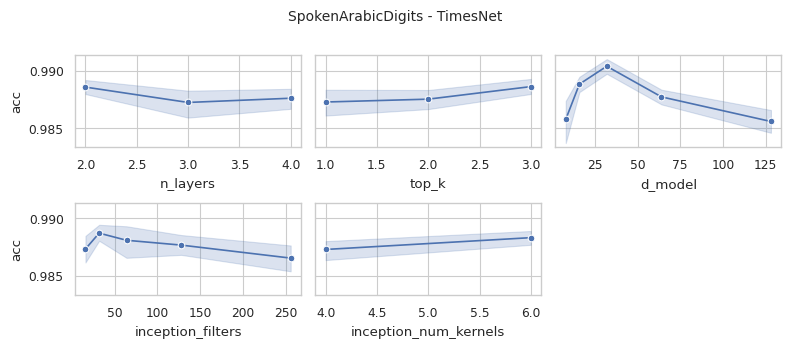

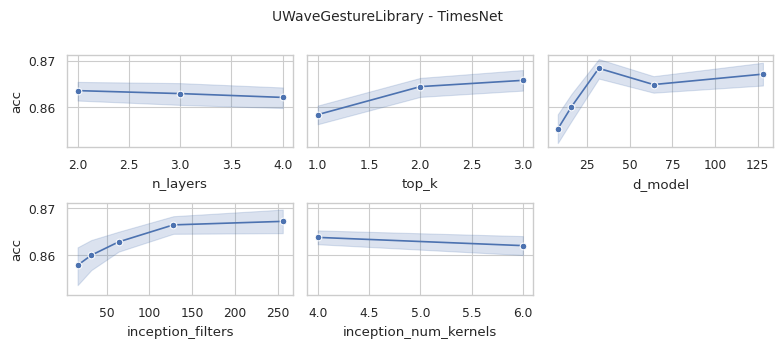

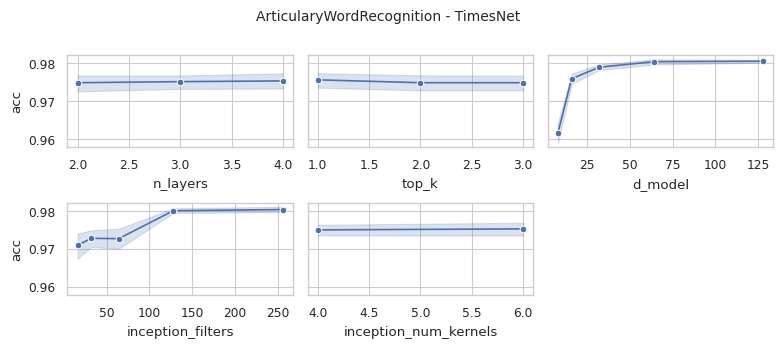

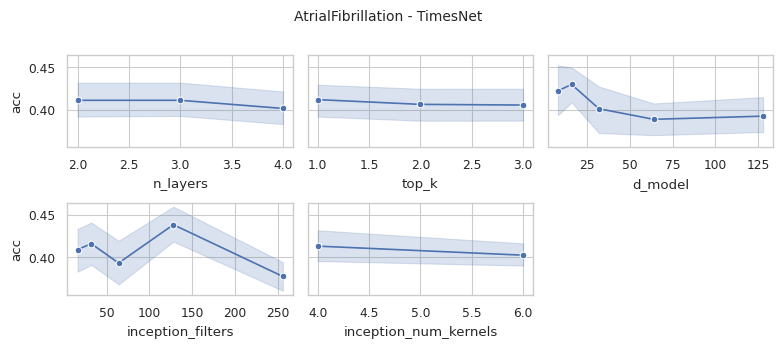

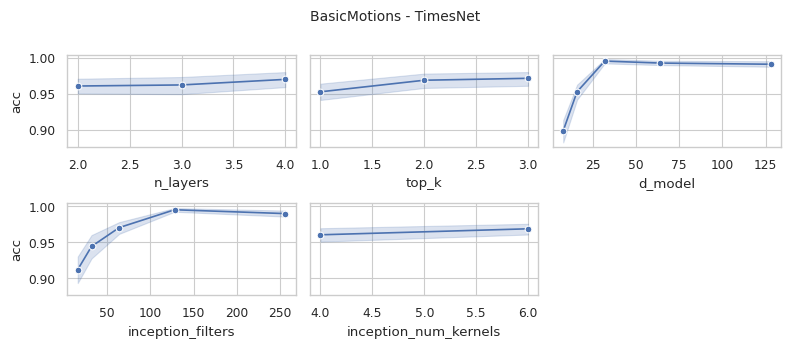

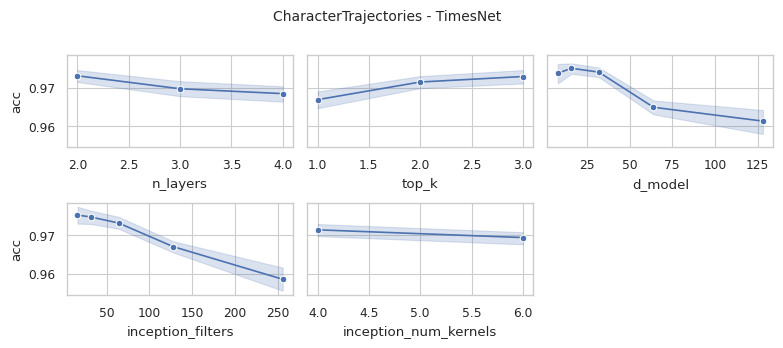

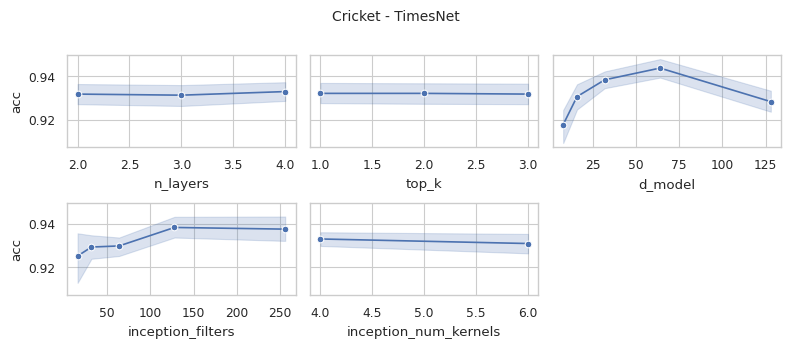

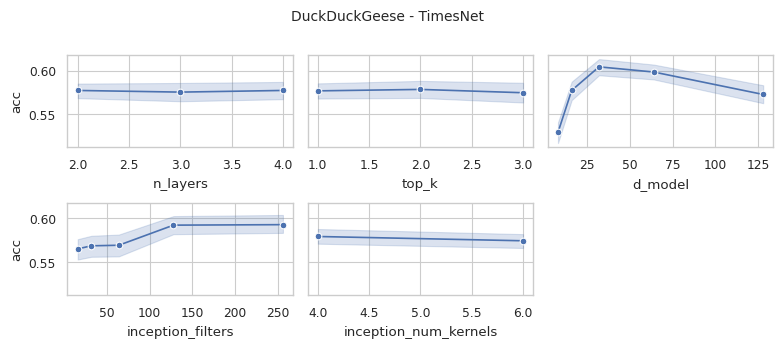

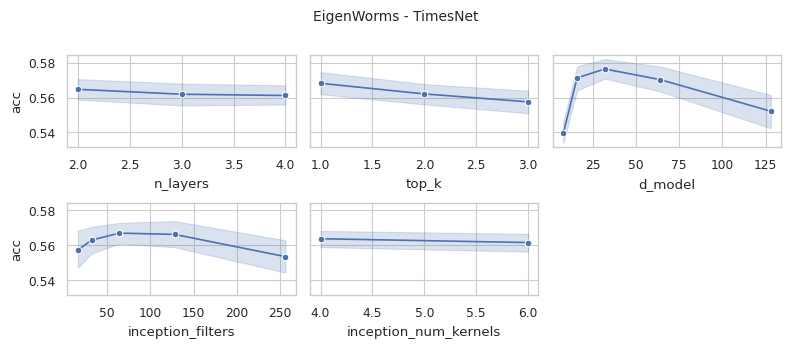

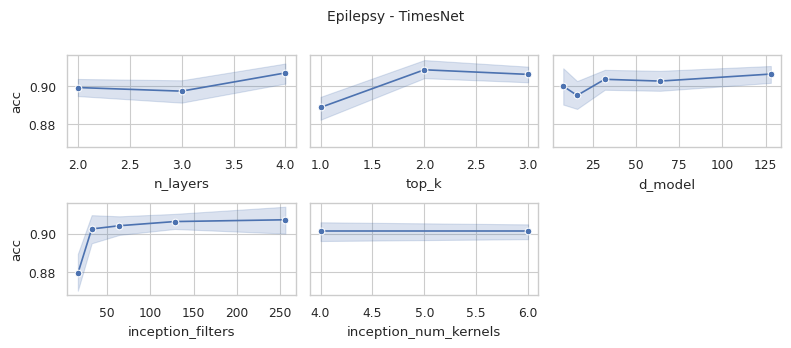

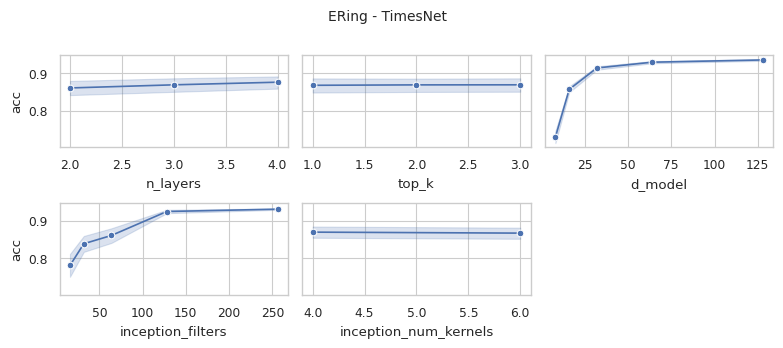

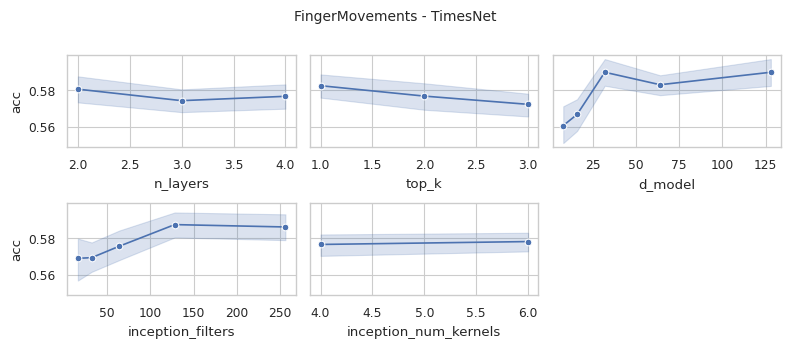

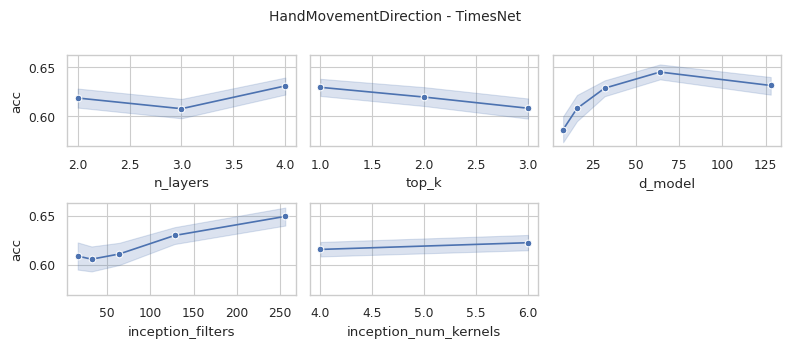

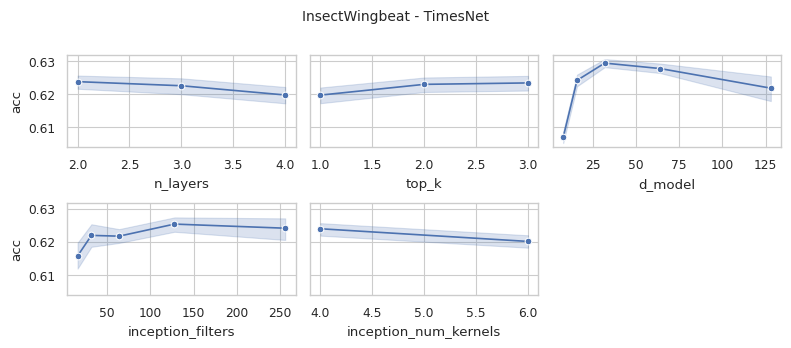

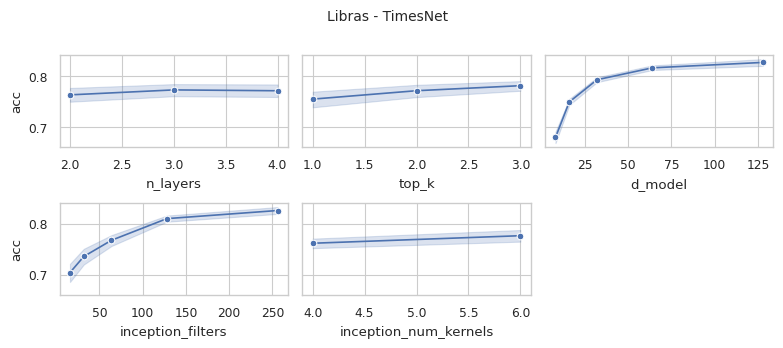

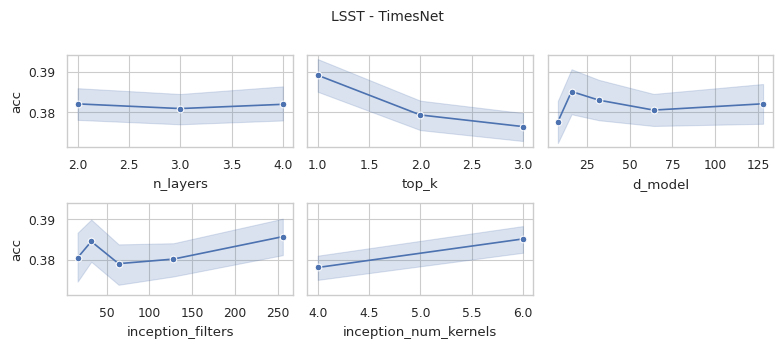

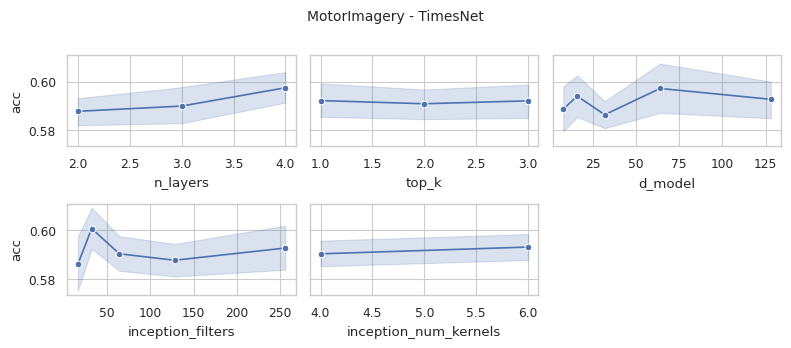

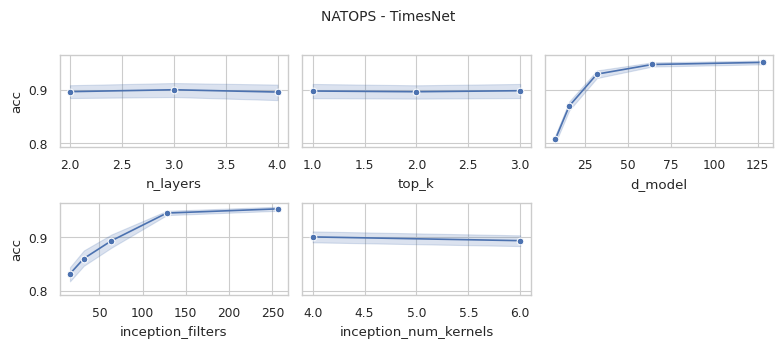

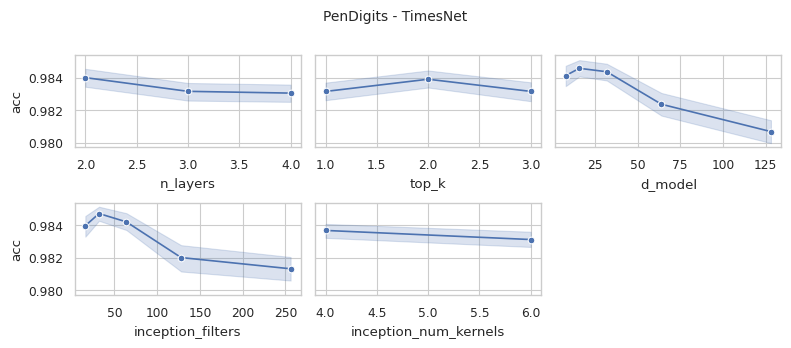

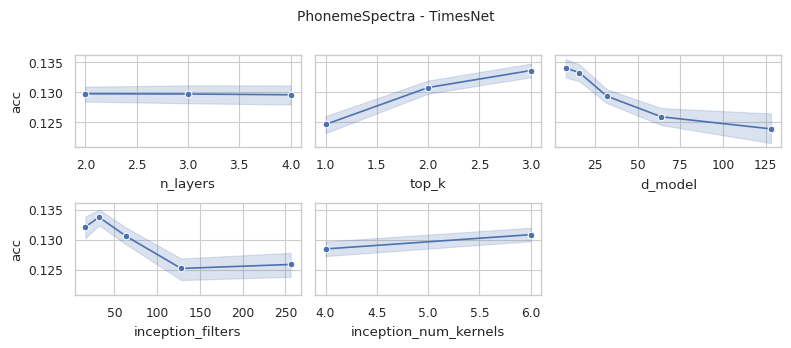

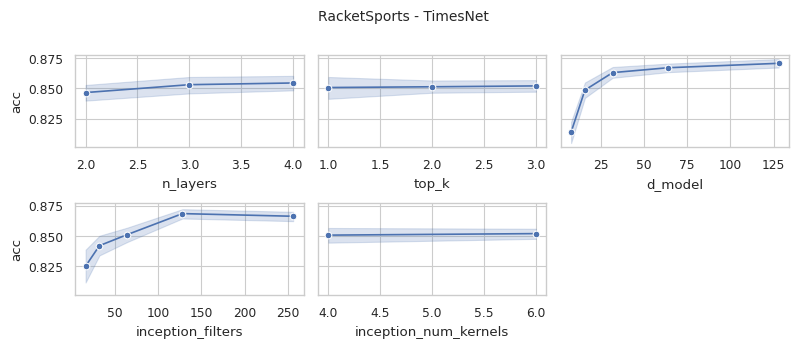

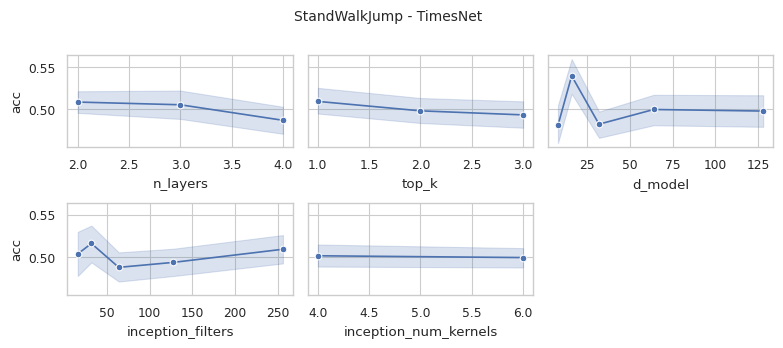

In [4]:
model = 'TimesNet'
result_dict = dict()

for data_name in UEA_MTSC30:
    
    if os.path.exists(f'../03-full_results/{model}/{model}_CLS_{data_name}.out'):
        with open(f'../03-full_results/{model}/{model}_CLS_{data_name}.out', 'r') as file:
            data = file.read().splitlines()
    else:
        print('no file')
        continue


    result_lst = list()
    for i in range(len(data)):
        if data[i].startswith('>>>>>>>testing : '):
            # el4_dm128_df256_nk6_tk3_Exp_0
            data_meta = list(data[i][16:-33].split('_'))
            data_meta[6] = int(data_meta[6].replace('sl', ''))
            data_meta[7] = int(data_meta[7].replace('ll', ''))
            data_meta[8] = int(data_meta[8].replace('pl', ''))
            data_meta[9] = int(data_meta[9].replace('el', ''))
            data_meta[10] = int(data_meta[10].replace('dm', ''))
            data_meta[11] = int(data_meta[11].replace('df', ''))
            data_meta[12] = int(data_meta[12].replace('nk', ''))
            data_meta[13] = int(data_meta[13].replace('tk', ''))

            acc = data[i+3].replace('accuracy:', '')
            model_params = data[i+4].replace('model parameter : ', '')
            model_size = data[i+5].replace('model size : ', '').replace('MB', '')

            result_data = {
                # 'task': data_meta[0],
                # 'task_id': data_meta[1],
                'data_name': data_meta[2],
                'model': data_meta[3],
                # 'data': data_meta[4],
                # 'feature': data_meta[5],
                'seq_len': data_meta[6],
                # 'label_len': data_meta[7],
                # 'pred_len': data_meta[8],
                'n_layers': data_meta[9],
                'd_model': data_meta[10],
                'inception_filters': data_meta[11],
                'inception_num_kernels': data_meta[12],
                'top_k': data_meta[13],
                # 'exp': data_meta[14],
                # 'desc': data_meta[15],
                'acc': float(acc),
                'model_params': int(model_params),
                'model_size (MB)': float(model_size)
            }

            result_lst.append(result_data)

    result_df = pd.DataFrame(result_lst)
    os.makedirs(f'./{model}', exist_ok=True)
    result_df.to_csv(f'./{model}/{data_name}.csv', index=False)
    result_dict[data_name] = result_df.copy()

    cols = ['n_layers', 'top_k', 'd_model', 'inception_filters', 'inception_num_kernels']
    num_cols, num_rows = 3, 2
    
    # # Boxplot
    # sns.set_theme(style="whitegrid")
    # sns.set_context("paper", font_scale=1)
    # fig, axs = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(8, 3.5), sharey=True)
    # for i, col in enumerate(cols):
    #     sns.boxplot(x=col, y='acc', data=result_df, ax=axs[i%num_cols], legend=False)
    # fig.suptitle(f'{data_name} - {model}', fontsize=10)
    # plt.tight_layout()
    # plt.subplots_adjust(top=0.85)
    # display(fig)
    # plt.close(fig)

    # Lineplot
    sns.set_theme(style="whitegrid")
    sns.set_context("paper", font_scale=1)
    fig, axs = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(8, 3.5), sharey=True)
    for i, col in enumerate(cols):
        if result_df[col].unique().size == 1: 
            sns.boxplot(x=col, y='acc', data=result_df, ax=axs[i//num_cols][i%num_cols], legend=False)
        else:
            sns.lineplot(x=col, y='acc', data=result_df, ax=axs[i//num_cols][i%num_cols], legend=False, style='model', markers=True)
    for i in range(len(cols), num_cols*num_rows):
        fig.delaxes(axs[i//num_cols][i%num_cols])
    fig.suptitle(f'{data_name} - {model}', fontsize=10)
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    display(fig)
    plt.savefig(f'./{model}/{data_name}.png', dpi=300, bbox_inches='tight')
    plt.close(fig)
    

    # # Lineplot where each line represents same hyperparameter combination except one
    # fig, axs = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(8, 3.5), sharey=True)
    # for i, col in enumerate(cols):
    #     col_rest = [c for c in cols if c != col]
    #     tmp_result = result_df.pivot_table(index=col_rest, columns=col, values='acc')
    #     tmp_result = pd.DataFrame(tmp_result.values, columns=tmp_result.columns)
    #     max_idx = tmp_result.mean(axis=1).idxmax()
    #     axs[i%num_cols].plot(tmp_result.T, marker='.', color='#111', alpha=0.2)
    #     axs[i%num_cols].plot(tmp_result.iloc[max_idx].T, marker='o', color='red', alpha=0.5)
    #     axs[i%num_cols].grid(False)
    #     axs[i%num_cols].set_xlabel(col)
    # fig.suptitle(f'{data_name} - {model}', fontsize=10)
    # plt.tight_layout()
    # plt.subplots_adjust(top=0.85)
    # display(fig)
    # plt.close(fig)
    
    
    

In [5]:
model_configs = {
    "e_layers" : [2,3,4],
    "d_model - d_ff" : [ 
        (8,16), (8,32), (8,64),
        (16,16), (16,32), (16,64),
        (32,32), (32,64), (32,128),
        (64,64), (64,128), (64,256),
        (128,128), (128,256),
    ],
    "top_k" : [1,2,3],
    "num_kernels" : [4,6],
}

hyperparameter_combinations = make_combination(model_configs)

acc_all_df = pd.DataFrame(index=UEA_MTSC30, 
                          columns=[str(hp_comb) for hp_comb in hyperparameter_combinations])
for data_name in UEA_MTSC30:
    acc_data_dict = dict()
    for hyperparameter_combination in hyperparameter_combinations:
        seq_len = data_info[f'CLS_{data_name}']["seq_len"]
        enc_in = data_info[f'CLS_{data_name}']["enc_in"]
        n_layers = hyperparameter_combination['e_layers']
        d_model, d_ff = hyperparameter_combination['d_model - d_ff']
        top_k = hyperparameter_combination['top_k']
        num_kernels = hyperparameter_combination['num_kernels']
        
        if result_dict.get(data_name) is None:
            continue

        tmp = result_dict[data_name]
        try:
            acc = tmp[
                (tmp['n_layers'] == n_layers)
                & (tmp['d_model'] == d_model)
                & (tmp['inception_filters'] == d_ff)
                & (tmp['inception_num_kernels'] == num_kernels)
                & (tmp['top_k'] == top_k)
            ]['acc'].values[0]
        except:
            acc = None
            print(f'no acc for {data_name} with {hyperparameter_combination}')
        acc_data_dict[str(hyperparameter_combination)] = acc

    acc_all_df.loc[data_name] = pd.Series(acc_data_dict)



In [6]:
acc_all_df.loc[:,'max'] = acc_all_df.max(axis=1)
acc_all_df.loc['avg'] = acc_all_df.mean(axis=0)
acc_all_df.sort_values(by='avg', ascending=False, inplace=True, axis=1)
acc_all_df

,max,"{'e_layers': 3, 'd_model - d_ff': (64, 128), 'top_k': 2, 'num_kernels': 6}","{'e_layers': 3, 'd_model - d_ff': (64, 128), 'top_k': 1, 'num_kernels': 6}","{'e_layers': 2, 'd_model - d_ff': (32, 128), 'top_k': 2, 'num_kernels': 4}","{'e_layers': 2, 'd_model - d_ff': (32, 128), 'top_k': 1, 'num_kernels': 4}","{'e_layers': 2, 'd_model - d_ff': (64, 256), 'top_k': 1, 'num_kernels': 4}","{'e_layers': 4, 'd_model - d_ff': (32, 32), 'top_k': 2, 'num_kernels': 6}","{'e_layers': 4, 'd_model - d_ff': (32, 32), 'top_k': 1, 'num_kernels': 6}","{'e_layers': 3, 'd_model - d_ff': (64, 128), 'top_k': 3, 'num_kernels': 6}","{'e_layers': 3, 'd_model - d_ff': (32, 128), 'top_k': 3, 'num_kernels': 4}",...,"{'e_layers': 3, 'd_model - d_ff': (8, 32), 'top_k': 2, 'num_kernels': 4}","{'e_layers': 4, 'd_model - d_ff': (8, 16), 'top_k': 2, 'num_kernels': 6}","{'e_layers': 3, 'd_model - d_ff': (8, 64), 'top_k': 1, 'num_kernels': 6}","{'e_layers': 4, 'd_model - d_ff': (8, 16), 'top_k': 3, 'num_kernels': 6}","{'e_layers': 3, 'd_model - d_ff': (8, 16), 'top_k': 1, 'num_kernels': 4}","{'e_layers': 2, 'd_model - d_ff': (8, 16), 'top_k': 3, 'num_kernels': 4}","{'e_layers': 2, 'd_model - d_ff': (8, 16), 'top_k': 2, 'num_kernels': 4}","{'e_layers': 4, 'd_model - d_ff': (8, 16), 'top_k': 1, 'num_kernels': 6}","{'e_layers': 3, 'd_model - d_ff': (8, 32), 'top_k': 1, 'num_kernels': 4}","{'e_layers': 2, 'd_model - d_ff': (8, 16), 'top_k': 1, 'num_kernels': 4}"
EthanolConcentration,0.334601,0.311787,0.311787,0.285171,0.285171,0.307985,0.281369,0.281369,0.311787,0.292776,...,0.292776,0.26616,0.285171,0.26616,0.285171,0.292776,0.292776,0.26616,0.292776,0.292776
FaceDetection,0.701476,0.671112,0.673666,0.674801,0.685868,0.674801,0.69126,0.673666,0.676504,0.68076,...,0.691544,0.688138,0.689274,0.68899,0.687287,0.678774,0.685017,0.692395,0.695516,0.677923
Handwriting,0.375294,0.351765,0.348235,0.342353,0.331765,0.345882,0.338824,0.350588,0.338824,0.322353,...,0.269412,0.257647,0.310588,0.274118,0.211765,0.241176,0.249412,0.254118,0.264706,0.238824
Heartbeat,0.839024,0.770732,0.770732,0.77561,0.770732,0.75122,0.765854,0.75122,0.77561,0.770732,...,0.756098,0.77561,0.8,0.785366,0.756098,0.760976,0.765854,0.780488,0.760976,0.760976
JapaneseVowels,0.986486,0.978378,0.972973,0.962162,0.964865,0.972973,0.962162,0.964865,0.975676,0.981081,...,0.918919,0.972973,0.908108,0.967568,0.894595,0.937838,0.924324,0.945946,0.924324,0.92973
PEMS-SF,0.878613,0.843931,0.83237,0.878613,0.878613,0.82659,0.867052,0.867052,0.843931,0.815029,...,0.763006,0.815029,0.872832,0.809249,0.803468,0.83237,0.803468,0.815029,0.774566,0.797688
SelfRegulationSCP1,0.921502,0.911263,0.887372,0.904437,0.901024,0.911263,0.897611,0.897611,0.901024,0.901024,...,0.890785,0.894198,0.890785,0.90785,0.890785,0.887372,0.887372,0.904437,0.894198,0.894198
SelfRegulationSCP2,0.6,0.527778,0.544444,0.55,0.533333,0.544444,0.566667,0.566667,0.522222,0.566667,...,0.527778,0.55,0.55,0.55,0.55,0.577778,0.555556,0.55,0.544444,0.533333
SpokenArabicDigits,0.995452,0.984084,0.99045,0.994088,0.993633,0.987267,0.993179,0.992724,0.984538,0.994543,...,0.990905,0.974989,0.976353,0.983174,0.984084,0.988631,0.982265,0.984084,0.982265,0.985903
UWaveGestureLibrary,0.884375,0.871875,0.871875,0.859375,0.85,0.8625,0.88125,0.871875,0.871875,0.878125,...,0.85625,0.8375,0.853125,0.84375,0.86875,0.86875,0.86875,0.828125,0.85,0.846875


In [7]:
pd.set_option("display.precision", 14)
acc_all_df.iloc[:,[0,1]]*100

,max,"{'e_layers': 3, 'd_model - d_ff': (64, 128), 'top_k': 2, 'num_kernels': 6}"
EthanolConcentration,33.46007604562737,31.1787072243346
FaceDetection,70.14755959137344,67.11123723041997
Handwriting,37.52941176470588,35.17647058823529
Heartbeat,83.90243902439025,77.07317073170732
JapaneseVowels,98.64864864864865,97.83783783783784
PEMS-SF,87.86127167630057,84.39306358381504
SelfRegulationSCP1,92.15017064846417,91.12627986348123
SelfRegulationSCP2,60.0,52.77777777777778
SpokenArabicDigits,99.54524783992724,98.40836743974533
UWaveGestureLibrary,88.4375,87.1875
